Imports

In [2]:
!pip install networkx
!pip install pennylane
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import time

# Import the core logic from your unified engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    total_qubits
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== 1. GRAPH SETUP & BASELINE ===


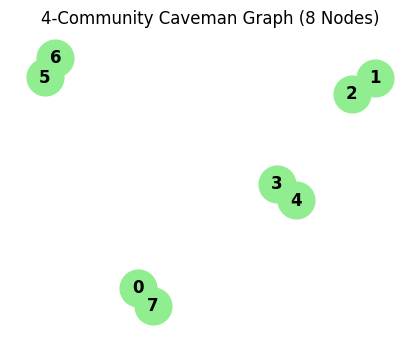

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.750000
Total Qubits Required: 16


In [4]:
print("=== 1. GRAPH SETUP & BASELINE ===")

# Generate the 8-node (4 communities of 2 nodes) Caveman Graph
G_test = nx.connected_caveman_graph(l=4, k=2)
k_target = 4
n_nodes = G_test.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# Visualize the graph
plt.figure(figsize=(4, 3))
nx.draw(G_test,  with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700)
plt.title(f"4-Community Caveman Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline using the exact modularity math
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_test, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [5]:
# =============================================================
# SECTION: ENTANGLEMENT VS NO ENTANGLEMENT
# Replicates Section VI-D and Table 10 from the paper
# =============================================================

H_comm = build_k_community_hamiltonian(G_test, k_target)

print("=== ENTANGLEMENT VS NO ENTANGLEMENT (k=4 Community Detection) ===")

n_seeds = 10
ent_results = {"entanglement": [], "no_entanglement": []}
rows = []

for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_ent = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=False
    )
    t_ent = time.time() - t0
    rho_ent = -res_ent['final_cost'] / true_baseline
    ent_results["entanglement"].append(rho_ent)
    print(f"  With entanglement    → ρ = {rho_ent:.4f}  ({t_ent:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_ent,
        "Time_s":    t_ent,
    })

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_no = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=True
    )
    t_no = time.time() - t0
    rho_no = -res_no['final_cost'] / true_baseline
    ent_results["no_entanglement"].append(rho_no)
    print(f"  Without entanglement → ρ = {rho_no:.4f}  ({t_no:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE No Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_no,
        "Time_s":    t_no,
    })

df_ent_community = pd.DataFrame(rows)
df_ent_community.to_csv("data_entanglement_community.csv", index=False)
print(f"\nSaved to data_entanglement_community.csv")
print(df_ent_community.to_string(index=False))

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
for label, rhos in ent_results.items():
    rhos_arr = np.array(rhos)
    print(f"\n{label}:")
    print(f"  best  = {rhos_arr.max():.4f}")
    print(f"  mean  = {rhos_arr.mean():.4f} ± {rhos_arr.std():.4f}")
    print(f"  >0.99 = {(rhos_arr > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos_arr > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos_arr > 0.90).mean()*100:.1f}%")

=== ENTANGLEMENT VS NO ENTANGLEMENT (k=4 Community Detection) ===

Seed 1/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (38.6s)
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Without entanglement → ρ = 0.8333  (42.7s)

Seed 2/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (38.5s)
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Without entanglement → ρ = 0.8333  (43.2s)

Seed 3/10
  Layer 0  (16 params) ... cost = -0.375000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (38.4s)
  Layer 0  (16 params) ... cost = -0.375000
  Layer 1  (76 params) ... cost = -0.375000
  Without entanglement → ρ = 0.5000  (41.5s)

Seed 4/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Wi

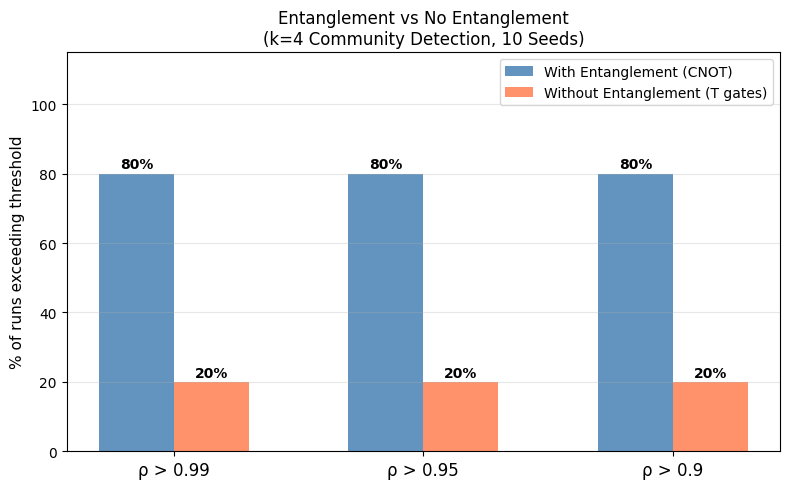

In [6]:
# =============================================================
# PLOT 1: Success rate by threshold - mirrors Table 10 from paper
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_community = pd.read_csv("data_entanglement_community.csv")
ent_arr = df_ent_community[df_ent_community["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_arr  = df_ent_community[df_ent_community["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

thresholds = [0.99, 0.95, 0.90]
x = np.arange(len(thresholds))
width = 0.3

ent_pct = [(ent_arr > t).mean() * 100 for t in thresholds]
no_pct  = [(no_arr  > t).mean() * 100 for t in thresholds]

plt.figure(figsize=(8, 5))
bars_ent = plt.bar(x - width/2, ent_pct, width,
                   label="With Entanglement (CNOT)",
                   color="steelblue", alpha=0.85)
bars_no  = plt.bar(x + width/2, no_pct, width,
                   label="Without Entanglement (T gates)",
                   color="coral", alpha=0.85)

for bar in bars_ent:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')
for bar in bars_no:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')

plt.xticks(x, [f"ρ > {t}" for t in thresholds], fontsize=12)
plt.ylabel("% of runs exceeding threshold", fontsize=11)
plt.title("Entanglement vs No Entanglement\n(k=4 Community Detection, 10 Seeds)",
          fontsize=12)
plt.ylim(0, 115)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

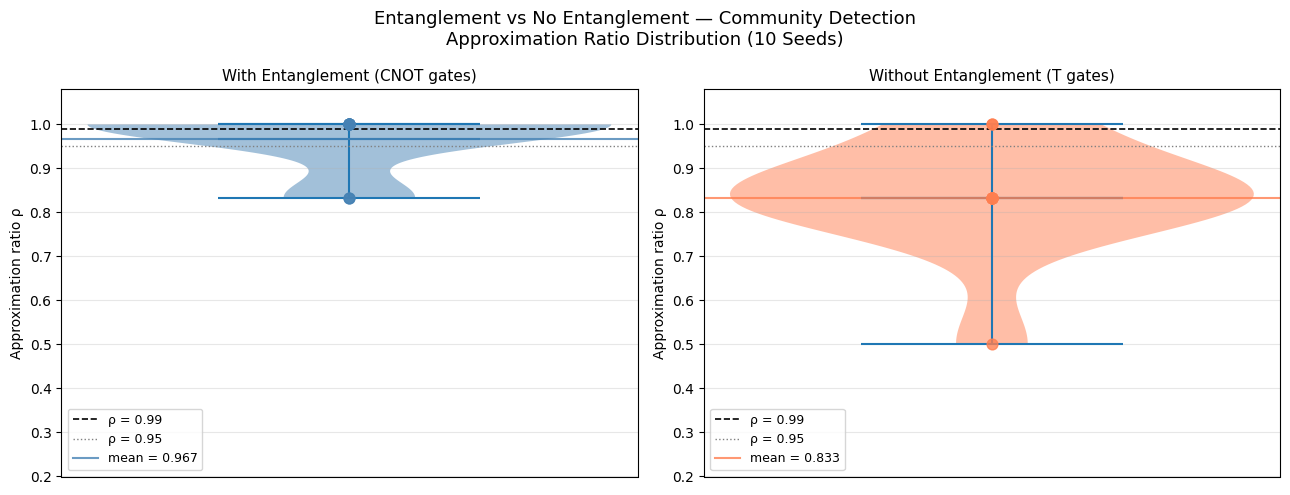

In [7]:
# =============================================================
# PLOT 2: Distribution violin plot
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_community = pd.read_csv("data_entanglement_community.csv")
ent_arr = df_ent_community[df_ent_community["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_arr  = df_ent_community[df_ent_community["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Entanglement vs No Entanglement — Community Detection\n"
             "Approximation Ratio Distribution (10 Seeds)", fontsize=13)

for ax, rhos, color, title in zip(
    axes,
    [ent_arr, no_arr],
    ["steelblue", "coral"],
    ["With Entanglement (CNOT gates)",
     "Without Entanglement (T gates)"]
):
    vp = ax.violinplot([rhos], positions=[1],
                       showmeans=True, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    ax.scatter([1]*len(rhos), rhos,
               color=color, alpha=0.8, s=60, zorder=3)

    ax.axhline(0.99, color="black", linestyle="--",
               linewidth=1.2, label="ρ = 0.99")
    ax.axhline(0.95, color="gray", linestyle=":",
               linewidth=1.0, label="ρ = 0.95")
    ax.axhline(rhos.mean(), color=color, linestyle="-",
               linewidth=1.5, alpha=0.8,
               label=f"mean = {rhos.mean():.3f}")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Approximation ratio ρ", fontsize=10)
    ax.set_ylim(0.2, 1.08)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

=== Finite shots experiment ===

In [8]:
for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")
    
    rng = np.random.default_rng(seed)
    res_ent = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=1000,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=False
    )
    rho_ent = -res_ent['final_cost'] / true_baseline
    print(f"  With entanglement    → ρ = {rho_ent:.4f}")
    rows.append({"Algorithm": "L-VQE Entanglement",
                 "Nodes": n_nodes, "Seed": seed,
                 "p_or_L": 1, "Rho": rho_ent})

    rng = np.random.default_rng(seed)
    res_no = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=1000,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=True
    )
    rho_no = -res_no['final_cost'] / true_baseline
    print(f"  Without entanglement → ρ = {rho_no:.4f}")
    rows.append({"Algorithm": "L-VQE No Entanglement",
                 "Nodes": n_nodes, "Seed": seed,
                 "p_or_L": 1, "Rho": rho_no})

df = pd.DataFrame(rows)
df['Rho'] = df['Rho'].clip(upper=1.0)
df.to_csv("data_entanglement_community_shots1000.csv", index=False)
print("\nDone. Saved to data_entanglement_community_shots1000.csv")

for label in ["L-VQE Entanglement", "L-VQE No Entanglement"]:
    rhos = df[df["Algorithm"] == label]["Rho"].values
    print(f"\n{label}:")
    print(f"  mean = {rhos.mean():.4f} ± {rhos.std():.4f}")
    print(f"  >0.99 = {(rhos > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos > 0.90).mean()*100:.1f}%")


Seed 1/10
  Layer 0  (16 params) ... 

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -0.624344
  Layer 1  (76 params) ... cost = -0.747312
  With entanglement    → ρ = 0.9992
  Layer 0  (16 params) ... cost = -0.624563
  Layer 1  (76 params) ... cost = -0.623469
  Without entanglement → ρ = 0.8308

Seed 2/10
  Layer 0  (16 params) ... cost = -0.624219
  Layer 1  (76 params) ... cost = -0.748594
  With entanglement    → ρ = 0.9991
  Layer 0  (16 params) ... cost = -0.624781
  Layer 1  (76 params) ... cost = -0.624187
  Without entanglement → ρ = 0.8316

Seed 3/10
  Layer 0  (16 params) ... cost = -0.375000
  Layer 1  (76 params) ... cost = -0.748719
  With entanglement    → ρ = 1.0000
  Layer 0  (16 params) ... cost = -0.374625
  Layer 1  (76 params) ... cost = -0.374437
  Without entanglement → ρ = 0.4996

Seed 4/10
  Layer 0  (16 params) ... cost = -0.623594
  Layer 1  (76 params) ... cost = -0.749719
  With entanglement    → ρ = 0.9981
  Layer 0  (16 params) ... cost = -0.624437
  Layer 1  (76 params) ... cost = -0.623937
  Without entanglement → ρ = 0.8326

S

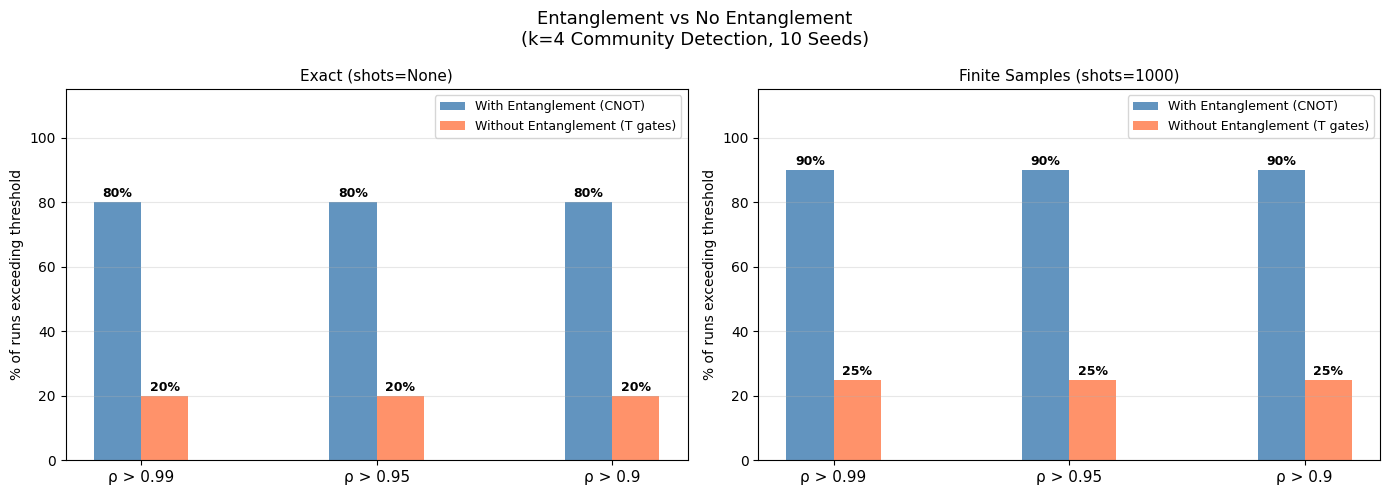

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_shots = pd.read_csv("data_entanglement_community_shots1000.csv")
df_exact = pd.read_csv("data_entanglement_community.csv")
df_exact['Rho'] = df_exact['Rho'].clip(upper=1.0)
df_shots['Rho'] = df_shots['Rho'].clip(upper=1.0)

ent_exact = df_exact[df_exact["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_exact  = df_exact[df_exact["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values
ent_shots = df_shots[df_shots["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_shots  = df_shots[df_shots["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

thresholds = [0.99, 0.95, 0.90]
x = np.arange(len(thresholds))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Entanglement vs No Entanglement\n(k=4 Community Detection, 10 Seeds)", fontsize=13)

for ax, ent, no, title in zip(
    axes,
    [ent_exact, ent_shots],
    [no_exact, no_shots],
    ["Exact (shots=None)", "Finite Samples (shots=1000)"]
):
    ent_pct = [(ent > t).mean() * 100 for t in thresholds]
    no_pct  = [(no  > t).mean() * 100 for t in thresholds]

    bars_ent = ax.bar(x - width/2, ent_pct, width,
                      label="With Entanglement (CNOT)",
                      color="steelblue", alpha=0.85)
    bars_no  = ax.bar(x + width/2, no_pct,  width,
                      label="Without Entanglement (T gates)",
                      color="coral", alpha=0.85)

    for bar in bars_ent:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{bar.get_height():.0f}%",
                ha='center', fontsize=9, fontweight='bold')
    for bar in bars_no:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{bar.get_height():.0f}%",
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([f"ρ > {t}" for t in thresholds], fontsize=11)
    ax.set_ylabel("% of runs exceeding threshold", fontsize=10)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("entanglement_community_bar_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

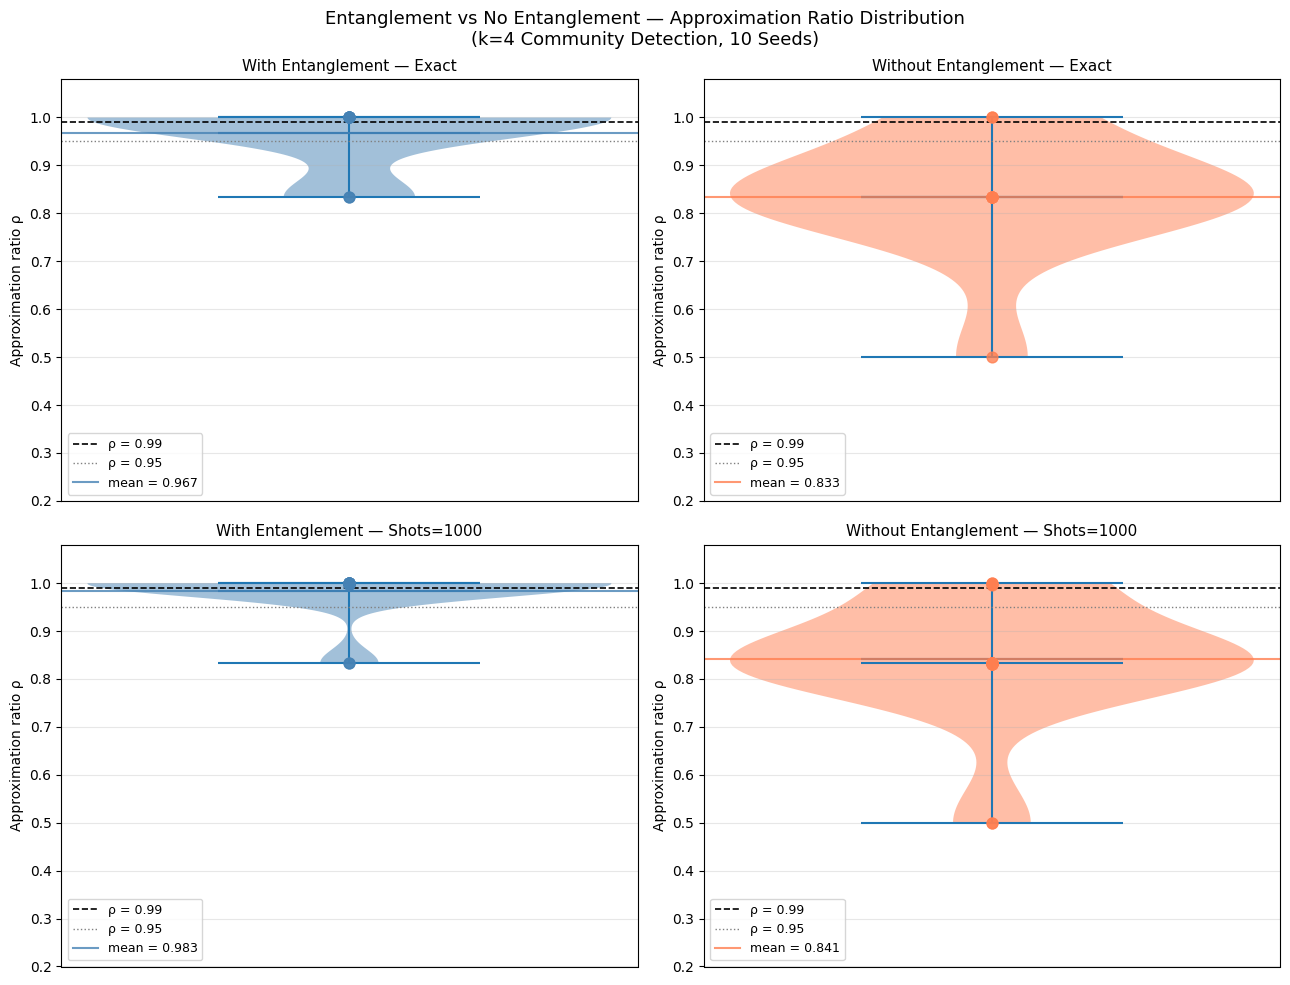

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Entanglement vs No Entanglement — Approximation Ratio Distribution\n"
             "(k=4 Community Detection, 10 Seeds)", fontsize=13)

datasets = [
    (ent_exact, "steelblue", "With Entanglement — Exact"),
    (no_exact,  "coral",     "Without Entanglement — Exact"),
    (ent_shots, "steelblue", "With Entanglement — Shots=1000"),
    (no_shots,  "coral",     "Without Entanglement — Shots=1000"),
]

for ax, (rhos, color, title) in zip(axes.flatten(), datasets):
    vp = ax.violinplot([rhos], positions=[1], showmeans=True, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    ax.scatter([1]*len(rhos), rhos, color=color, alpha=0.8, s=60, zorder=3)
    ax.axhline(0.99, color="black", linestyle="--", linewidth=1.2, label="ρ = 0.99")
    ax.axhline(0.95, color="gray",  linestyle=":",  linewidth=1.0, label="ρ = 0.95")
    ax.axhline(rhos.mean(), color=color, linestyle="-",
               linewidth=1.5, alpha=0.8, label=f"mean = {rhos.mean():.3f}")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Approximation ratio ρ", fontsize=10)
    ax.set_ylim(0.2, 1.08)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("entanglement_community_violin_comparison.png", dpi=150, bbox_inches='tight')
plt.show()